In [176]:
# Numerical operations (arrays, math, vectorized computation)
import numpy as np
# Data manipulation and analysis (DataFrame, CSV handling, cleaning)
import pandas as pd
# Visualization (plots, graphs, model evaluation visuals)
import matplotlib.pyplot as plt
# Stratified train-test split (keeps category proportions same)
from sklearn.model_selection import StratifiedShuffleSplit
# Handling missing values (mean, median, most_frequent, constant)
from sklearn.impute import SimpleImputer
# Feature scaling (standardization: mean=0, std=1)
from sklearn.preprocessing import StandardScaler
# Creating ML pipelines (clean → scale → model)
from sklearn.pipeline import Pipeline
# Applying different preprocessing to different columns
from sklearn.compose import ColumnTransformer
# Linear regression model (baseline regression algorithm)
from sklearn.linear_model import LinearRegression
# Decision Tree regression model (non-linear, rule-based)
from sklearn.tree import DecisionTreeRegressor
# Random Forest regression (ensemble of decision trees)
from sklearn.ensemble import RandomForestRegressor
# Regression error metric (Root Mean Squared Error)
from sklearn.metrics import root_mean_squared_error
# Cross-validation for robust model evaluation
from sklearn.model_selection import cross_val_score
# R² score (how well the model explains variance)
from sklearn.metrics import r2_score
# Accuracy metric (⚠️ meant for classification, not regression)
from sklearn.metrics import accuracy_score

In [177]:
data = pd.read_csv("StudentMarksDataset.csv").drop(["Std_Name","Std_Branch","Std_Course","Std_RollNo"],axis = 1)

In [178]:
data.head()

,Std_StudyHours,Std_Marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [179]:
data.tail()

,Std_StudyHours,Std_Marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [180]:
data.describe()

,Std_StudyHours,Std_Marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


Text(0.5, 1.0, 'Plotting of Marks vs Study Hours')

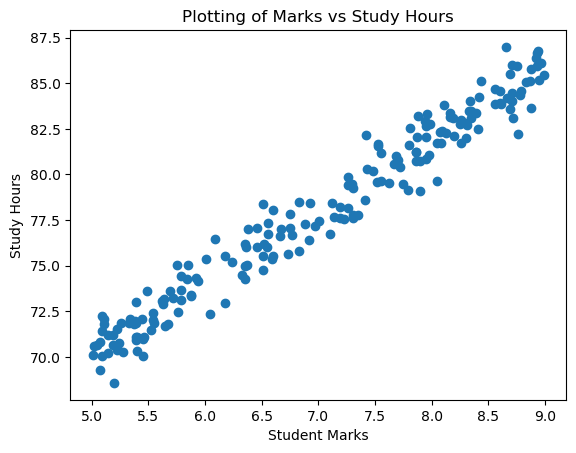

In [181]:
#Plotting marks vs Study hours graph
plt.scatter(data['Std_StudyHours'],data['Std_Marks'])
plt.xlabel("Student Marks")
plt.ylabel("Study Hours")
plt.title("Plotting of Marks vs Study Hours")

array([[<Axes: title={'center': 'Std_StudyHours'}>,
        <Axes: title={'center': 'Std_Marks'}>]], dtype=object)

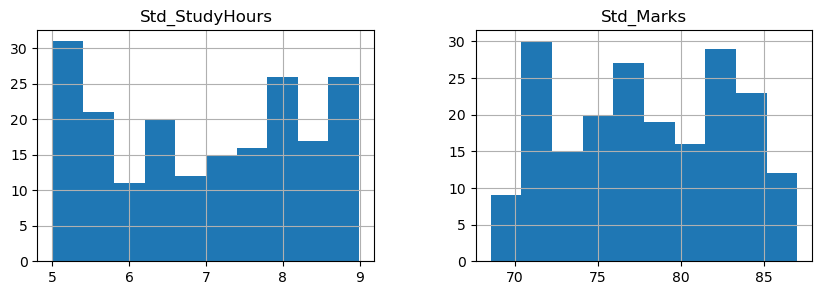

In [182]:
#plotting Hitograph
data.hist(bins = 10,figsize=(10,3))

In [183]:
np.array(set(data['Std_StudyHours']))

array({5.67, 6.83, 7.1, 7.75, 8.67, 6.56, 7.55, 6.67, 8.99, 5.19, 6.75, 8.56, 8.19, 5.07, 5.75, 6.18, 6.93, 7.43, 8.71, 8.93, 8.25, 8.79, 8.07, 8.75, 8.11, 8.39, 8.61, nan, 5.11, 5.54, 5.72, 5.79, 5.22, 6.04, 6.36, 6.97, 7.86, 7.72, 7.79, 5.4, 5.01, 5.65, 5.33, 5.26, 6.51, 6.01, 6.33, 5.76, 7.9, nan, 7.01, 7.26, 8.44, 8.72, 8.26, 8.69, 8.76, 8.83, 8.33, 8.97, 8.08, 8.87, 8.94, 5.37, 5.05, 5.94, 5.62, 5.44, 6.55, 6.37, 5.69, 5.55, 7.19, 7.94, 7.69, 7.12, 7.62, 7.3, 7.87, 7.8, 5.09, 5.52, 5.34, 5.84, 5.02, 6.59, 6.73, 6.66, 6.09, 6.52, 7.48, 7.41, 7.52, 7.23, 7.98, 8.34, 8.41, 8.16, 8.3, 8.09, 8.05, 8.2, nan, 8.95, 8.66, nan, 5.88, 5.45, 5.63, 5.2, 5.38, 6.88, 6.38, 7.88, 7.31, 7.95, 7.81, 7.7, 5.85, 5.49, 5.92, 5.24, 6.35, 6.24, 6.92, 6.6, 7.67, 7.42, 7.99, 7.35, 8.13, 8.78, 8.92, 8.88, 8.31, 8.6, 8.35, 8.42, nan, 6.77, 5.28, 5.46, 5.39, 5.64, 5.14, 6.46, 7.96, 7.14, 7.53},
      dtype=object)

In [184]:
#Stratiffied splitting
data['Study_cat'] = pd.cut(data['Std_StudyHours'],bins = [0,2,4,6,8,10],labels = [1,2,3,4,5])

In [185]:
data_create = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_data,test_data in data_create.split(data,data['Study_cat'].cat.add_categories(0).fillna(0)):
    train_set = data.loc[train_data].drop("Study_cat",axis = 1)
    test_set = data.loc[test_data].to_csv("test_data.csv",index=False)

In [186]:
#Copy
data_copy = train_set.copy()
data_copy

,Std_StudyHours,Std_Marks
141,7.43,80.31
91,8.20,82.10
45,6.18,72.96
157,6.18,75.52
7,8.99,85.46
...,...,...
102,8.26,82.99
67,8.26,81.70
85,5.63,72.87
49,5.09,71.41


In [187]:
#Dropping the target values
data_copy = train_set.drop("Std_Marks",axis = 1)

In [188]:
data_predictions = train_set["Std_Marks"].copy()

In [189]:
num_attributes = data_copy.columns.tolist()

In [190]:
#Creating pipeline
num_pipeline = Pipeline([
    ("numerica",SimpleImputer(strategy="median")),
    ("standardize",StandardScaler())
])

In [191]:
#Applying Column Transfer
full_pipline = ColumnTransformer([
    ("cat",num_pipeline,num_attributes)
])

In [192]:
final_data = full_pipline.fit_transform(data_copy)

In [193]:
#Creating Model
print("Linear Model")
lin_reg = LinearRegression()
lin_model = lin_reg.fit(final_data,data_predictions)
lin_predictions = lin_model.predict(final_data)
lin_rmse = root_mean_squared_error(data_predictions, lin_pred)
r2_percent = r2_score(data_predictions, lin_pred) * 100
print(lin_predictions)
print(lin_rmse)
print(r2_percent)

Linear Model
[79.58821112 82.62346325 74.66085375 74.66085375 85.73755311 73.47828798
 72.84758624 84.90975707 78.44506421 73.32061254 84.63382506 72.13804678
 76.98656643 78.91809051 82.82055755 81.59857292 80.53426373 85.30394566
 79.9823997  71.58618275 84.63382506 75.33097435 70.75838671 81.44089749
 75.25213663 82.46578782 84.23963647 79.11518481 71.74385819 79.54879226
 81.63799178 83.49067815 83.21474614 70.87664329 71.78327705 75.96167609
 73.12351825 85.10685137 81.63799178 78.78012451 84.04254218 71.54676389
 83.21474614 71.50734503 78.6421585  77.93261904 83.01765184 70.79780557
 76.82889099 71.78327705 82.46578782 76.31644582 70.95548101 77.22307958
 78.28738877 72.17746564 72.72932966 75.7645818  79.11518481 72.57165423
 81.75624836 76.90772871 78.91809051 85.65871539 80.65252031 73.00526167
 81.28322205 74.30608402 71.54676389 82.34753124 84.43673076 73.3600314
 71.31025074 81.32264091 85.50103996 79.78530541 70.56129242 81.67741064
 73.63596342 76.11935153 79.94298085 70

In [194]:
#random Forest
ran_reg = RandomForestRegressor()
ran_model = ran_reg.fit(final_data,data_predictions)
ran_predictions = ran_model.predict(final_data)
per_error = root_mean_squared_error(data_predictions,ran_predictions)
r2_accuracy = r2_score(data_predictions,ran_predictions) * 100
print(np.array(ran_predictions))
print(per_error)
print(r2_accuracy)

[80.6953     82.422145   74.39485143 74.39485143 85.5943     73.45762714
 73.3522     83.9327     77.408325   74.16246    84.9512     72.11359167
 76.940525   79.2487696  82.641175   82.43973429 80.684      84.81203095
 81.36688571 70.79234    84.9512     75.61407    70.73720095 80.14557571
 74.90791333 82.970865   83.97603833 78.25920306 71.4995     81.1637
 81.56091429 83.90712    83.34695    70.74019    70.6925     76.46239333
 73.1878     85.0424     81.56091429 76.93501619 84.275225   71.34633929
 83.34695    71.71297    77.78140111 77.5104     82.71813    69.35334952
 76.231925   70.6925     82.970865   76.75203333 70.758825   77.195825
 77.051      71.93509    73.1002     76.76226    78.25920306 72.1642
 81.519775   77.32384167 79.2487696  85.7831     80.7782     73.1461
 81.21854167 75.1493     71.34633929 82.48590667 85.963      74.47046
 71.7703     81.79630667 86.30666714 80.0922     70.76097405 82.67011929
 74.16514    76.381      80.13466905 71.23292381 70.79234    80.1455

In [195]:
#Decision Tree
tree_reg = DecisionTreeRegressor()
tree_model = tree_reg.fit(final_data,data_predictions)
tree_predictions = tree_model.predict(final_data)
per_tree_error = root_mean_squared_error(data_predictions,tree_predictions)
r2_accuracy_tree = r2_score(data_predictions,tree_predictions) * 100
print(np.array(tree_predictions))
print(per_tree_error)
print(r2_accuracy_tree)

[80.31       82.1        74.24       74.24       85.46       73.37
 73.25       84.35       77.65       74.25       85.21       72.195
 76.7        79.64       82.79       82.93       80.58       84.71
 81.62       70.72       85.21       75.58       70.92       79.93
 74.49       83.255      83.87       78.20666667 72.08       82.18
 81.445      84.24       83.29       70.80333333 70.51       76.57
 73.14       85.04       81.445      76.87       84.28       71.29333333
 83.29       71.94       77.92       77.46       82.84       68.57
 75.65       70.51       83.255      76.8        70.78       77.15
 76.76       71.83       73.61       77.07       78.20666667 71.7
 81.08       77.445      79.64       86.12       80.81       72.46
 80.985      76.48       71.29333333 82.27       86.99       75.02
 71.85       82.04       86.305      80.17       70.71       83.33
 74.34       76.03       79.56       71.22666667 70.72       79.93
 84.19       71.45       77.78       77.33       84.    

In [196]:
data_test = pd.read_csv("test_data.csv").drop("Study_cat",axis = 1)

In [197]:
predictions = full_pipline.fit_transform(data_test)
target_value = data_test["Std_Marks"].copy()
final_predictions = tree_model.predict(predictions)
pd.DataFrame(final_predictions,columns=["predicted_marks"]).to_csv("prediction.csv",index = False)
error = root_mean_squared_error(target_value,final_predictions)
r2_per = r2_score(target_value,final_predictions)